# Хардовые сигналы: последние три года

Все публикуемые метрики относятся только к периоду **2023-09-02…2026-09-02**. Более ранние данные используются только как прошлое для причинных признаков и walk-forward выбора.

- **Momentum, низкий уровень и выход вниз — «сейчас выгодно»**: hit означает, что в следующие `h` публикаций не было более низкого `rub_per_unit`.
- Для низкого уровня `(L,q)` задают только причинный trigger; процентильное условие не подменяет forward-hit.
- **Выход вверх — «окно закрывается»**: hit означает `P[T+h] > P[T]`.

Используются только `h=2/3/4/5`. Lift равен `hit_rate_signal / hit_rate_random`. Экономическая выгода считается отдельно:

$$
benefit_{T,h}=\left(\frac{mean(P_{T-h},\ldots,P_{T+h})}{P_T}-1\right)\cdot 10000.
$$

На графиках оставлены только сами значения lift, выгоды и частоты. Hit rates, доверительные интервалы и p-value сохраняются в CSV для статистической проверки, но не перегружают визуализации.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULT_DIR = ROOT / 'data' / 'processed' / 'hard_signals'

spike_fixed = pd.read_csv(RESULT_DIR / 'metrics.csv', parse_dates=['first_signal', 'last_signal'])
spike_wf_all = pd.read_csv(RESULT_DIR / 'walk_forward_metrics.csv', parse_dates=['first_signal', 'last_signal'])
spike_wf = spike_wf_all.copy()
spike_selections = pd.read_csv(RESULT_DIR / 'walk_forward_selections.csv', parse_dates=['fold_start', 'fold_end'])
spike_recent = pd.read_csv(RESULT_DIR / 'recent_walk_forward_metrics.csv', parse_dates=['requested_period_start', 'data_as_of', 'first_signal', 'last_signal'])

alternative_fixed = pd.read_csv(RESULT_DIR / 'alternative_metrics.csv', parse_dates=['first_signal', 'last_signal'])
alternative_wf = pd.read_csv(RESULT_DIR / 'alternative_walk_forward_metrics.csv', parse_dates=['first_signal', 'last_signal'])
alternative_selections = pd.read_csv(RESULT_DIR / 'alternative_walk_forward_selections.csv', parse_dates=['fold_start', 'fold_end'])
alternative_recent = pd.read_csv(RESULT_DIR / 'alternative_recent_walk_forward_metrics.csv', parse_dates=['requested_period_start', 'data_as_of', 'first_signal', 'last_signal'])
coverage = pd.read_csv(RESULT_DIR / 'policy_coverage.csv')
hard_screen = pd.read_csv(RESULT_DIR / 'hard_signal_screen.csv')
level_policy_screen = pd.read_csv(RESULT_DIR / 'level_policy_screen.csv')
qualified_level_frequency = pd.read_csv(RESULT_DIR / 'qualified_level_frequency.csv')
corridor_level_screen = pd.read_csv(RESULT_DIR / 'corridor_level_policy_screen.csv')
corridor_level_frequency = pd.read_csv(RESULT_DIR / 'corridor_level_frequency.csv')
relaxed_wf = pd.read_csv(RESULT_DIR / 'relaxed_walk_forward_candidates.csv')
metadata = json.loads((RESULT_DIR / 'metadata.json').read_text())

horizons = [2, 3, 4, 5]
currencies = ['AMD', 'KGS', 'KZT', 'TJS', 'UZS']
period_order = ['весь OOT', 'посл. 5 г.', 'посл. 3 г.', 'посл. 2 г.', 'посл. 1 г.']


In [2]:
def annotated_heatmap(ax, frame, title, show_y=True, cmap='RdYlGn',
                      vmin=.7, vmax=1.3, fmt='.2f'):
    values = frame.to_numpy(float)
    image = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(np.arange(frame.shape[1]), frame.columns, rotation=30, ha='right')
    ax.set_yticks(np.arange(frame.shape[0]))
    if show_y:
        ax.set_yticklabels(frame.index)
    else:
        ax.tick_params(axis='y', labelleft=False)
    for row in range(frame.shape[0]):
        for column in range(frame.shape[1]):
            value = values[row, column]
            label = '—' if np.isnan(value) else format(value, fmt)
            ax.text(column, row, label, ha='center', va='center', fontsize=8, fontweight='bold')
    ax.set_title(title)
    return image


def metric_matrix(data, metric):
    return (data.pivot(index='currency', columns='horizon', values=metric)
            .reindex(index=currencies, columns=horizons)
            .rename(columns=lambda value: f'h={int(value)}'))


def plot_walk_forward_dashboard(data, title):
    lift = metric_matrix(data, 'hit_lift')
    benefit = metric_matrix(data, 'benefit_bps')
    frequency = metric_matrix(data, 'signals_per_week')
    benefit_limit = max(10., float(np.ceil(np.nanmax(np.abs(benefit.to_numpy())) / 10) * 10))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    image = annotated_heatmap(axes[0], lift, 'lift к случайному дню',
                              cmap='RdYlGn', vmin=.6, vmax=1.4)
    fig.colorbar(image, ax=axes[0], pad=.02, label='lift')
    image = annotated_heatmap(axes[1], benefit, 'экономическая выгода',
                              cmap='RdYlGn', vmin=-benefit_limit, vmax=benefit_limit, fmt='.1f')
    fig.colorbar(image, ax=axes[1], pad=.02, label='bp')
    image = annotated_heatmap(axes[2], frequency, 'частота',
                              cmap='YlGn', vmin=0, vmax=2)
    fig.colorbar(image, ax=axes[2], pad=.02, label='сигналов в неделю')
    fig.suptitle(f'{title} · walk-forward · последние 3 года', fontsize=14)
    plt.tight_layout(); plt.show()



def plot_selected_momentum_n(selections):
    report_start = pd.Timestamp(metadata['report_start'])
    data_as_of = pd.Timestamp(metadata['data_as_of'])
    selected = selections.loc[
        selections['fold_end'].gt(report_start)
        & selections['fold_start'].le(data_as_of)
    ].copy()
    selected['N'] = pd.to_numeric(
        selected['strategy_id'].str.extract(r'momentum_streak_(\d+)d', expand=False)
    )
    deployment_years = sorted(selected['fold_start'].dt.year.unique())

    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8), sharey=True)
    for ax, horizon in zip(axes, horizons):
        part = selected[selected['selection_horizon'].eq(horizon)].copy()
        part['year'] = part['fold_start'].dt.year
        matrix = (part.pivot(index='currency', columns='year', values='N')
                  .reindex(index=currencies, columns=deployment_years))
        image = annotated_heatmap(
            ax, matrix, f'h={horizon}', show_y=ax is axes[0],
            cmap='YlGn', vmin=1, vmax=5, fmt='.0f',
        )
        ax.set_xlabel('год deployment fold')
    fig.colorbar(image, cax=fig.add_axes([.925, .18, .012, .62]), label='выбранное N')
    fig.suptitle('Momentum · результат перебора N только на прошлом', fontsize=14)
    fig.subplots_adjust(left=.07, right=.90, bottom=.18, top=.82, wspace=.15)
    plt.show()

def add_spike_n(frame):
    result = frame.copy()
    result['N'] = pd.to_numeric(
        result['strategy_id'].str.extract(r'momentum_streak_(\d+)d', expand=False)
    )
    return result


def spike_matrix(data, horizon, metric):
    return (data[data['horizon'].eq(horizon)]
            .pivot(index='currency', columns='N', values=metric)
            .reindex(index=currencies, columns=[2, 3, 4, 5])
            .rename(columns=lambda value: f'N={int(value)}'))


def plot_fixed_spikes(frame):
    data = add_spike_n(frame)
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8), sharey=True)
    for ax, horizon in zip(axes, horizons):
        image = annotated_heatmap(ax, spike_matrix(data, horizon, 'hit_lift'),
                                  f'h={horizon}', show_y=ax is axes[0], vmin=.6, vmax=1.4)
    fig.colorbar(image, cax=fig.add_axes([.925, .18, .012, .62]), label='lift')
    fig.suptitle('Momentum · фиксированные N × h · lift · последние 3 года', fontsize=14)
    fig.subplots_adjust(left=.07, right=.90, bottom=.18, top=.82, wspace=.15)
    plt.show()

    limit = max(10., float(np.ceil(data['benefit_bps'].abs().max() / 10) * 10))
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.8), sharey=True)
    for ax, horizon in zip(axes, horizons):
        image = annotated_heatmap(ax, spike_matrix(data, horizon, 'benefit_bps'),
                                  f'h={horizon}', show_y=ax is axes[0],
                                  cmap='RdYlGn', vmin=-limit, vmax=limit, fmt='.1f')
    fig.colorbar(image, cax=fig.add_axes([.925, .18, .012, .62]), label='benefit, bp')
    fig.suptitle('Momentum · фиксированные N × h · выгода · последние 3 года', fontsize=14)
    fig.subplots_adjust(left=.07, right=.90, bottom=.18, top=.82, wspace=.15)
    plt.show()

    # Frequency is identical across evaluation horizons; use the first
    # available horizon only as a non-duplicated copy of the trigger stream.
    frequency = spike_matrix(data, horizons[0], 'signals_per_week')
    fig, ax = plt.subplots(figsize=(8, 4.8))
    image = annotated_heatmap(ax, frequency, 'частота фиксированных momentum-политик',
                              cmap='YlGn', vmin=0, vmax=1.5)
    fig.colorbar(image, ax=ax, pad=.02, label='сигналов в неделю')
    plt.tight_layout(); plt.show()



def plot_selected_level_parameters(selections):
    report_start = pd.Timestamp(metadata['report_start'])
    data_as_of = pd.Timestamp(metadata['data_as_of'])
    selected = selections.loc[
        selections['signal_family'].eq('level')
        & selections['fold_end'].gt(report_start)
        & selections['fold_start'].le(data_as_of)
    ].copy()
    parameters = selected['strategy_id'].str.extract(r'level_L(\d+)_p(\d+)')
    selected['L'] = pd.to_numeric(parameters[0])
    selected['q'] = pd.to_numeric(parameters[1])
    selected['year'] = selected['fold_start'].dt.year
    deployment_years = sorted(selected['year'].unique())

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)
    for ax, horizon in zip(axes, horizons):
        part = selected[selected['selection_horizon'].eq(horizon)]
        matrix_l = (part.pivot(index='currency', columns='year', values='L')
                    .reindex(index=currencies, columns=deployment_years))
        matrix_q = (part.pivot(index='currency', columns='year', values='q')
                    .reindex(index=currencies, columns=deployment_years))
        image = ax.imshow(matrix_l.to_numpy(float), cmap='Blues', vmin=20, vmax=250, aspect='auto')
        ax.set_xticks(np.arange(len(deployment_years)), deployment_years, rotation=30, ha='right')
        ax.set_yticks(np.arange(len(currencies)))
        if ax is axes[0]:
            ax.set_yticklabels(currencies)
        else:
            ax.tick_params(axis='y', labelleft=False)
        for row in range(len(currencies)):
            for column in range(len(deployment_years)):
                lookback = matrix_l.iloc[row, column]
                quantile = matrix_q.iloc[row, column]
                label = '—' if np.isnan(lookback) else f'L={lookback:.0f}\nq={quantile:.0f}%'
                ax.text(column, row, label, ha='center', va='center', fontsize=7.5, fontweight='bold')
        ax.set_title(f'h={horizon}')
        ax.set_xlabel('год deployment fold')
    fig.subplots_adjust(left=.07, right=.90, bottom=.18, top=.82, wspace=.15)
    fig.colorbar(image, cax=fig.add_axes([.925, .18, .012, .62]), label='lookback L')
    fig.suptitle('Низкий уровень · параметры, выбранные только на прошлом', fontsize=14)
    plt.show()

def plot_policy_map(frame, title):
    benefit_limit = max(10., float(np.nanpercentile(np.abs(frame['benefit_bps']), 95)))
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)
    for ax, horizon in zip(axes, horizons):
        part = frame[frame['horizon'].eq(horizon)]
        scatter = ax.scatter(part['signals_per_week'], part['hit_lift'],
                             c=part['benefit_bps'], cmap='RdYlGn',
                             vmin=-benefit_limit, vmax=benefit_limit,
                             s=30, alpha=.72)
        ax.axhline(1.3, color='black', linestyle='--')
        ax.axhline(1.0, color='#777', linestyle=':')
        ax.axvspan(1, 2, color='gold', alpha=.10)
        ax.set_xlim(left=0); ax.set_title(f'h={horizon}'); ax.set_xlabel('сигналов/нед.')
        ax.grid(alpha=.18)
    axes[0].set_ylabel('lift к случайному дню')
    fig.colorbar(scatter, cax=fig.add_axes([.925, .18, .012, .62]), label='benefit, bp')
    fig.suptitle(f'{title} · фиксированные политики · последние 3 года', fontsize=14)
    fig.subplots_adjust(left=.07, right=.90, bottom=.18, top=.82, wspace=.15)
    plt.show()


## Исключённые и пустые политики

В отчётном трёхлетнем окне `N=10` встретился только три раза суммарно по всем коридорам, `N=20` — ни разу. Они не участвуют ни в выборе, ни в расчёте lift и выгоды. Для остальных семейств пустые policy × corridor комбинации также исключаются: их метрики считаются неопределёнными, а не нулевыми.


/var/folders/jm/ghk67hlj78j_57lz1wh98rj80000gn/T/ipykernel_40057/706418793.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  excluded_long = coverage[coverage['strategy_id'].str.contains(r'momentum_streak_(10|20)d', regex=True)]


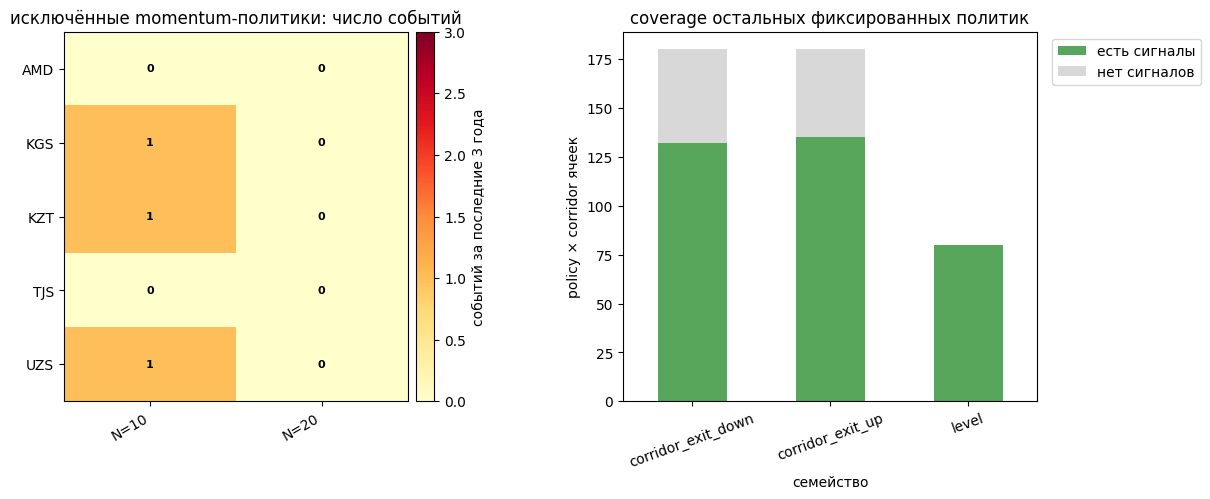

corridor_exit_down: исключено 48 из 180 policy × corridor ячеек из-за отсутствия сигналов
corridor_exit_up: исключено 45 из 180 policy × corridor ячеек из-за отсутствия сигналов
level: исключено 0 из 80 policy × corridor ячеек из-за отсутствия сигналов


In [3]:
excluded_long = coverage[coverage['strategy_id'].str.contains(r'momentum_streak_(10|20)d', regex=True)]
audit = (excluded_long.pivot(index='currency', columns='strategy_id', values='signal_count')
         .reindex(currencies).fillna(0))
audit.columns = ['N=10', 'N=20']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
image = annotated_heatmap(axes[0], audit, 'исключённые momentum-политики: число событий',
                          cmap='YlOrRd', vmin=0, vmax=max(3, audit.to_numpy().max()), fmt='.0f')
fig.colorbar(image, ax=axes[0], pad=.02, label='событий за последние 3 года')

alternative_coverage = coverage[coverage['signal_family'].isin(['level', 'corridor_exit_down', 'corridor_exit_up'])]
coverage_counts = (alternative_coverage.assign(
    status=lambda x: np.where(x['signal_count'].gt(0), 'есть сигналы', 'нет сигналов'))
    .groupby(['signal_family', 'status']).size().unstack(fill_value=0))
coverage_counts.plot.bar(stacked=True, ax=axes[1], color=['#58a65c', '#d8d8d8'])
axes[1].set_title('coverage остальных фиксированных политик')
axes[1].set_xlabel('семейство'); axes[1].set_ylabel('policy × corridor ячеек')
axes[1].tick_params(axis='x', rotation=20); axes[1].legend(title='', loc='upper left', bbox_to_anchor=(1.02, 1))
fig.subplots_adjust(right=.82, wspace=.35); plt.show()

for family, group in alternative_coverage.groupby('signal_family'):
    empty = int(group['signal_count'].eq(0).sum())
    print(f'{family}: исключено {empty} из {len(group)} policy × corridor ячеек из-за отсутствия сигналов')


# 1. Momentum / spike

### Пример пуша

> «Курс сомони снижается третий опубликованный день подряд».

Это только наблюдаемый факт о прошлом и настоящем. Продуктовый сценарий пуша — **«сейчас выгодно»**.

### Trigger

Для политики `N` сигнал возникает в первый день, когда серия достигает `N=2/3/4/5` последовательных снижений:

$$
P_T<P_{T-1}<\ldots<P_{T-N}.
$$

Все цены в trigger опубликованы не позднее T. Дополнительный cooldown между событиями одной фиксированной политики не применяется.

### Hit rate и lift

На горизонте `h=2/3/4/5` попадание означает, что ожидание не дало клиенту более низкого курса:

$$
hit^{momentum}_{T,h}=\mathbf 1\left[\min(P_{T+1},\ldots,P_{T+h})\ge P_T\right].
$$

`hit_rate_signal` — среднее этого индикатора по датам momentum-сигналов. `hit_rate_random` считается по равному числу случайных опубликованных дат того же коридора и трёхлетнего периода с тем же правилом попадания. Основная метрика:

$$
lift_h=\frac{hit\_rate\_signal_h}{hit\_rate\_random_h}.
$$

### Экономическая выгода и частота

Для каждой даты сигнала:

$$
benefit_{T,h}=\left(\frac{mean(P_{T-h},\ldots,P_{T+h})}{P_T}-1\right)\cdot10000\;bp.
$$

Итоговый `benefit_bps` — среднее по сигналам; отдельно в CSV проверяется гипотеза `E[benefit]>0`. Частота — число фактически выпущенных сигналов, делённое на число недель в отчётном периоде. Она зависит от `N`, но не от будущего горизонта `h` для уже фиксированной политики.

Ниже сначала показана полная карта фиксированных `N × h`. Она описывает гипотезы и не используется для ретроспективного выбора победителя.


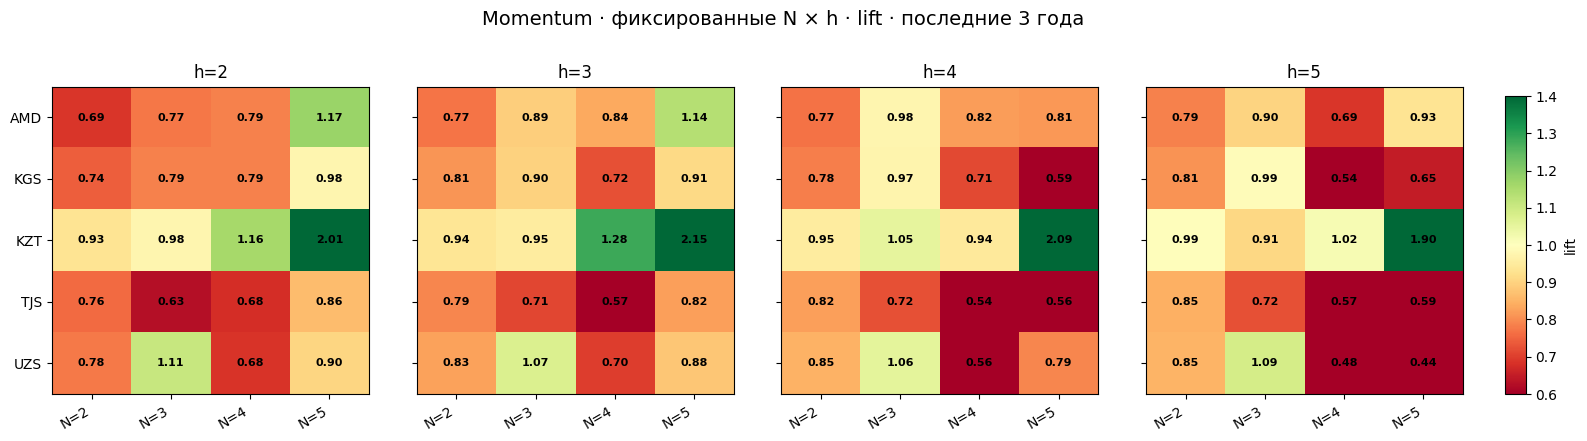

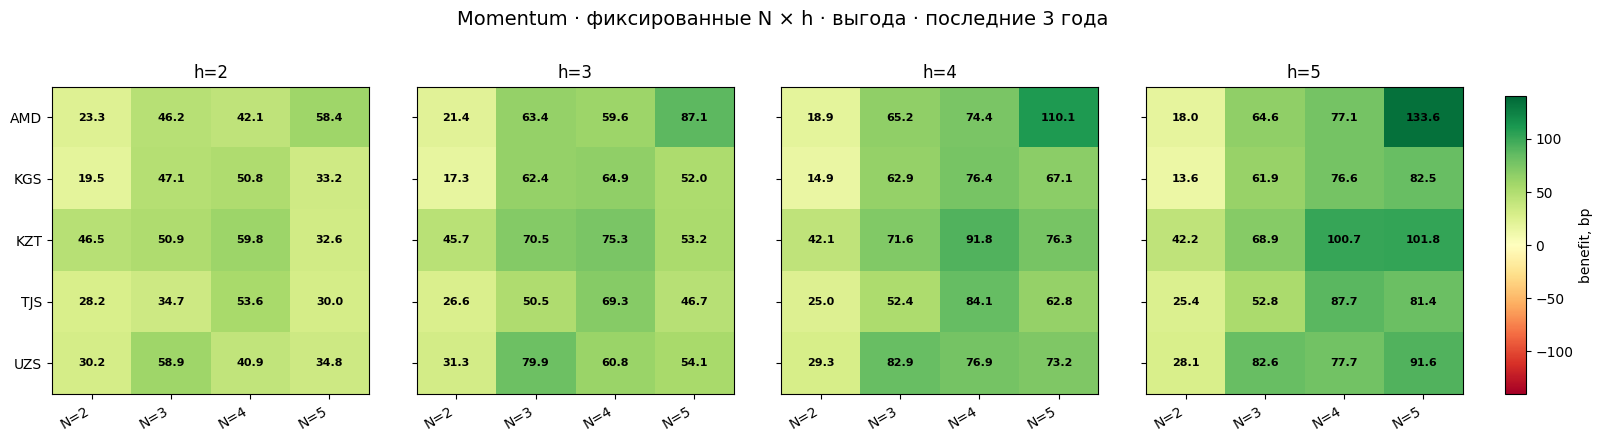

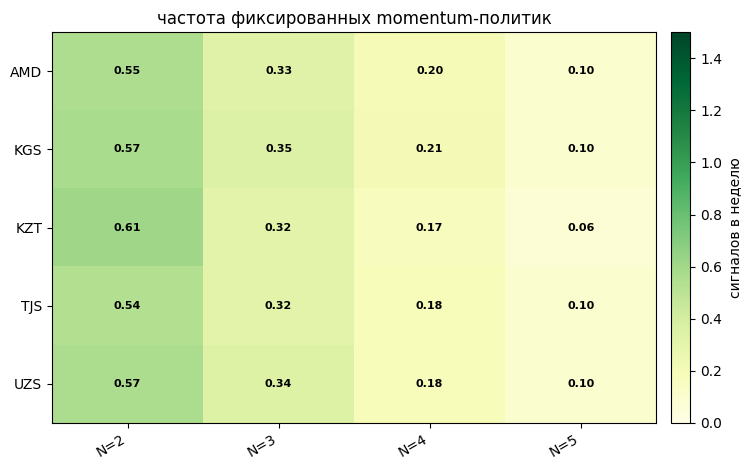

In [4]:
plot_fixed_spikes(spike_fixed)

## 1.1 Честный momentum walk-forward

Перебор `N=2/3/4/5` выполняется отдельно внутри каждого годового fold и только на данных, доступных до его начала. Первый график показывает **результат перебора**, а не lift: число в ячейке — выбранное N для конкретных коридора, `h` и года.

После выбора в out-of-time год выпускается только один поток. Поэтому следующий dashboard уже не имеет оси N:

- lift и частота относятся к реально выбранному и выпущенному потоку;
- экономическая выгода также относится к выбранному N каждого fold;
- это не выгода одного фиксированного `N=5`.

Результаты каждого фиксированного N, включая экономическую выгоду `N=5`, находятся в предыдущем разделе `Momentum · фиксированные N × h`. Там выбор по этим же данным не производится.

Ranking сначала проверяет достаточный размер обучающей выборки, затем `lift ≥ 1.2` и `benefit_bps ≥ −5`. Частота показывается, но по текущему решению не влияет на hard-only отбор. После исключения N=1 в разных fold выбираются параметры из `N=2/3/4/5`.


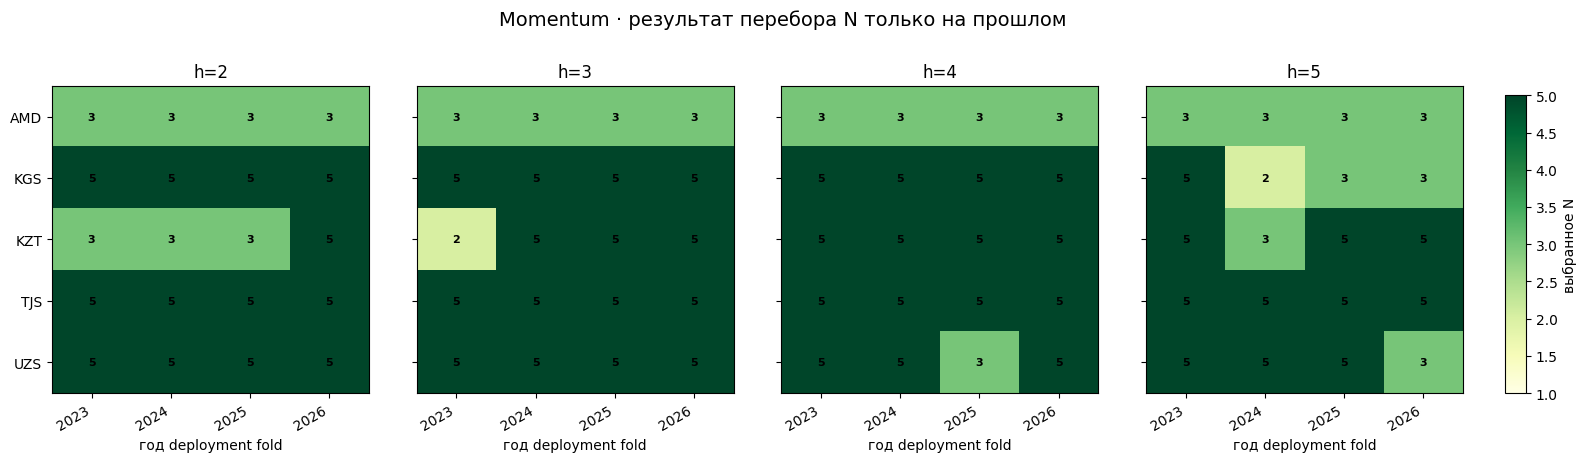

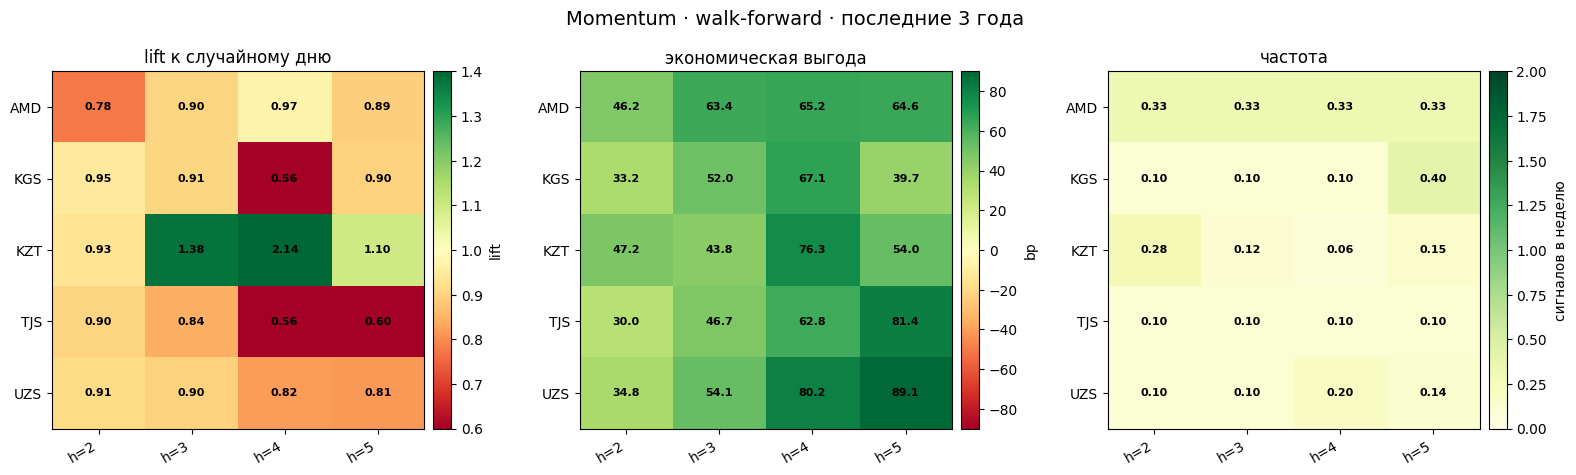

In [5]:
plot_selected_momentum_n(spike_selections)
plot_walk_forward_dashboard(spike_wf, 'Momentum')


# 2. Низкий уровень

### Пример пуша

> «Сейчас курс тенге ниже, чем в 90% опубликованных дней за последние 60 наблюдений».

Параметры такой политики: `L=60`, `q=0.90`. Текст сообщает наблюдаемый низкий уровень курса.


### Какие параметры перебираются

Полная заранее заданная сетка содержит 16 политик:

- `L = 20/60/120/250` предыдущих опубликованных наблюдений;
- `q = 70/80/90/95%` — минимальная доля предыдущих курсов, которые должны быть выше текущего.

График фиксированных политик содержит все 16 комбинаций `L × q` для каждого коридора и h. Walk-forward dashboard ниже показывает не одну общую пару: `L` и `q` заново выбираются на прошлом для каждого коридора, года и h. Отдельная визуализация перед dashboard показывает, какие именно параметры были выбраны.

### Trigger

Для каждой даты причинно рассчитывается доля предыдущих `L` курсов, которые были выше текущего:

$$
level_{T,L}=\frac{1}{L}\sum_{j=1}^{L}\mathbf 1[P_{T-j}>P_T].
$$

Сигнал возникает, если

$$
level_{T,L}\ge q.
$$

Между сигналами одной политики действует cooldown, чтобы ежедневное сохранение низкого уровня не превращалось в серию одинаковых пушей.

### Hit rate и lift

Параметры `(L,q)` определяют только момент trigger. Как требует кейс для сообщения «сейчас выгодно», hit проверяет решение клиента: после T в течение h публикаций не появился более выгодный, то есть более низкий курс:

$$
hit_{T,h}^{level}=\mathbf 1\left[P_T\leq\min(P_{T+1},\ldots,P_{T+h})\right].
$$

`hit_rate_signal` — среднее этого индикатора по датам level-сигналов. Для случайных опубликованных дат того же коридора и периода проверяется тот же forward-hit, после чего:

$$
lift_h=\frac{hit\_rate\_signal_h}{hit\_rate\_random_h}.
$$

Такой lift отвечает на вопрос, насколько чаще сигнал действительно отмечает день, после которого ожидание h публикаций не дало клиенту более низкого курса. Денежная величина преимущества отдельно измеряется `benefit_bps`.

### Экономическая выгода и частота

$$
benefit_{T,h}=\left(\frac{mean(P_{T-h},\ldots,P_{T+h})}{P_T}-1\right)\cdot10000\;bp.
$$

Положительный `benefit_bps` означает, что курс в T ниже среднего курса вокруг него. В CSV сохраняются 95% интервал и односторонний тест `E[benefit]>0`. Частота считается как число выпущенных после cooldown пушей на неделю трёхлетнего периода.


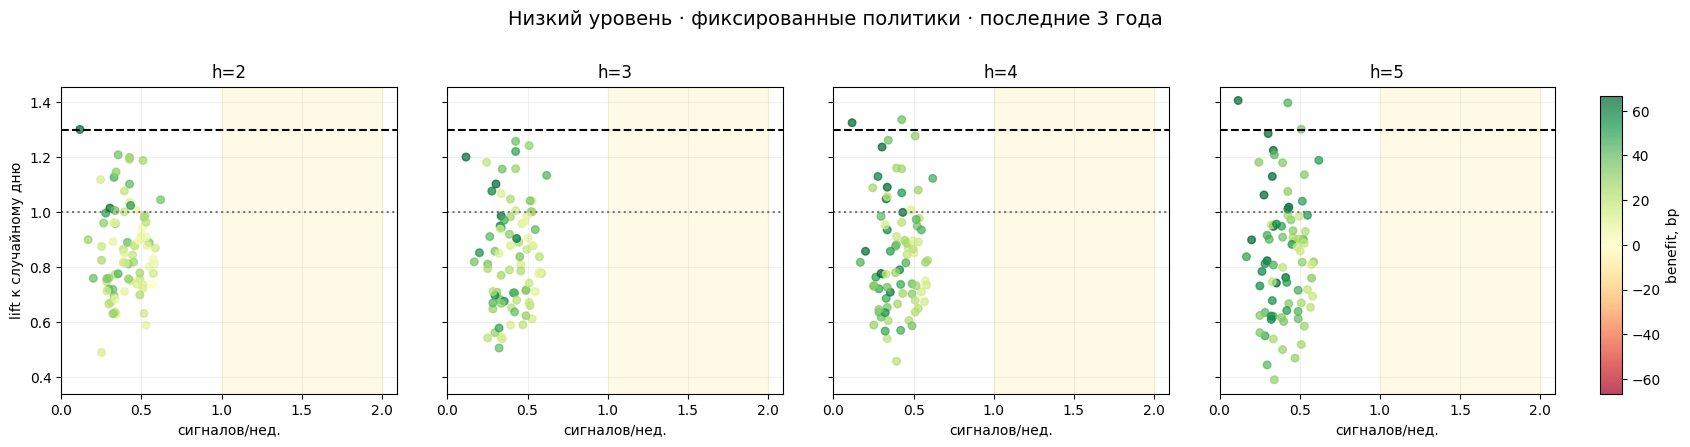

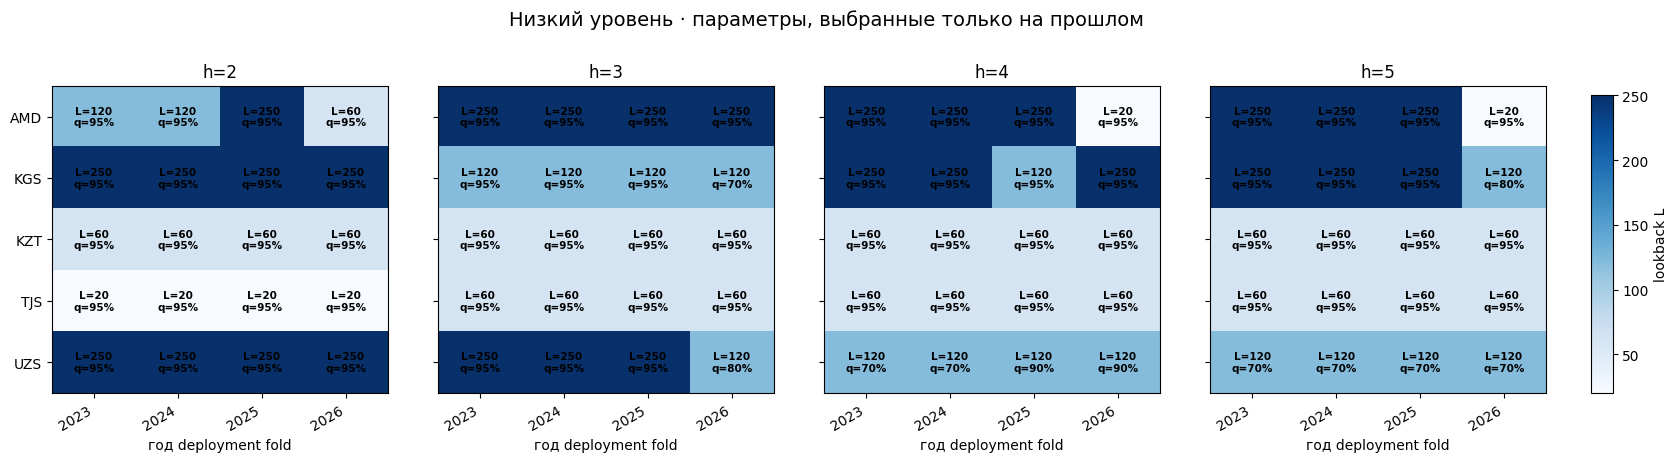

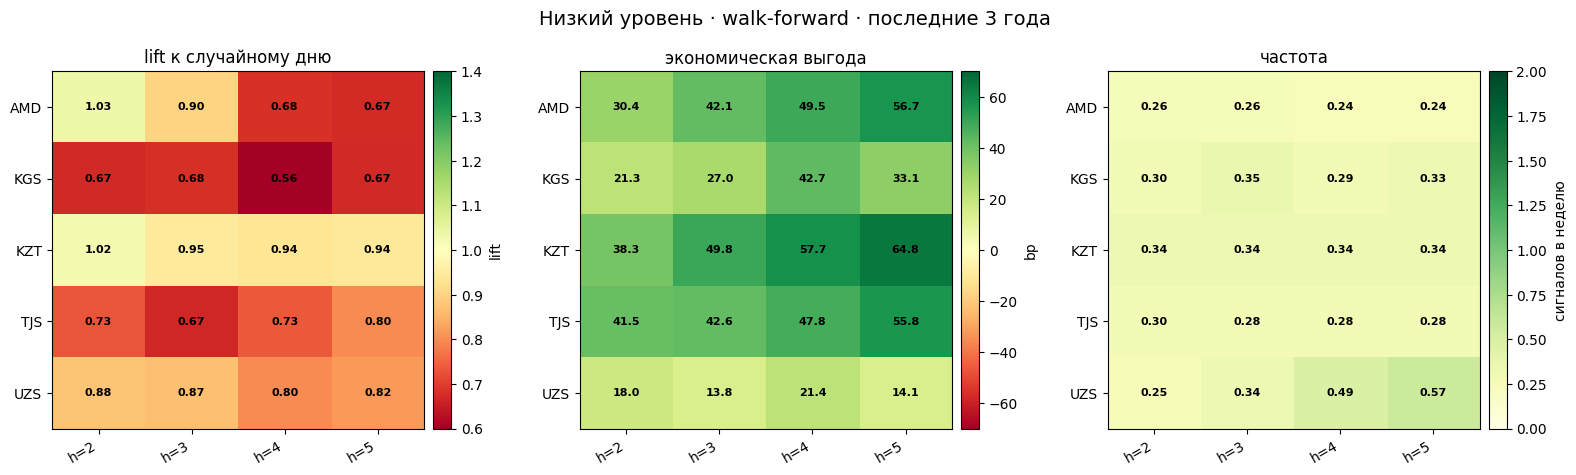

In [6]:
level_fixed = alternative_fixed[alternative_fixed['signal_family'].eq('level')]
plot_policy_map(level_fixed, 'Низкий уровень')

plot_selected_level_parameters(alternative_selections)

level_wf = alternative_wf[alternative_wf['signal_family'].eq('level')]
level_recent = alternative_recent[alternative_recent['signal_family'].eq('level')]
plot_walk_forward_dashboard(level_wf, 'Низкий уровень')


# 3. Выход из стабильного коридора

Само нахождение внутри коридора пуш не создаёт: у него нет направленного клиентского действия. Сигнал возникает только при первом наблюдаемом выходе.

### Примеры пушей

Выход вниз, сценарий **«сейчас выгодно»**:

> «Курс драма опустился ниже диапазона последних 10 публикаций».

Выход вверх, сценарий **«окно закрывается»**:

> «Курс драма поднялся выше диапазона последних 10 публикаций».

### Trigger

По предыдущим `L` публикациям, не включая T, определяются границы:

$$
low_T=\min(P_{T-L},\ldots,P_{T-1}),\qquad
high_T=\max(P_{T-L},\ldots,P_{T-1}).
$$

Предыдущий диапазон считается стабильным, если его ширина не превышает порог `r`:

$$
\left(\frac{high_T}{low_T}-1\right)\cdot10000\le r.
$$

С буфером выхода `b` сигнал вниз возникает при

$$
P_T<low_T\left(1-\frac{b}{10000}\right),
$$

а сигнал вверх — при

$$
P_T>high_T\left(1+\frac{b}{10000}\right).
$$

### Hit rate и lift

Для выхода вниз проверяется своевременность перевода сейчас:

$$
hit^{down}_{T,h}=\mathbf 1\left[\min(P_{T+1},\ldots,P_{T+h})\ge P_T\right].
$$

Для выхода вверх проверяется утверждение «окно закрывается»:

$$
hit^{up}_{T,h}=\mathbf 1[P_{T+h}>P_T].
$$

Случайные опубликованные даты того же коридора и периода проверяются по правилу соответствующего направления. Для каждого направления отдельно:

$$
lift_h=\frac{hit\_rate\_signal_h}{hit\_rate\_random_h}.
$$

### Экономическая выгода и частота

Для обоих направлений используется единая обязательная формула:

$$
benefit_{T,h}=\left(\frac{mean(P_{T-h},\ldots,P_{T+h})}{P_T}-1\right)\cdot10000\;bp.
$$

Для выхода вверх положительный hit при отрицательной выгоде недостаточен: индикатор может угадывать дальнейший рост уже после того, как выгодный момент был потерян. Частота считается отдельно для потоков выхода вниз и вверх. Пустые policy × corridor комбинации исключаются до оценки и перечислены в coverage-блоке выше.


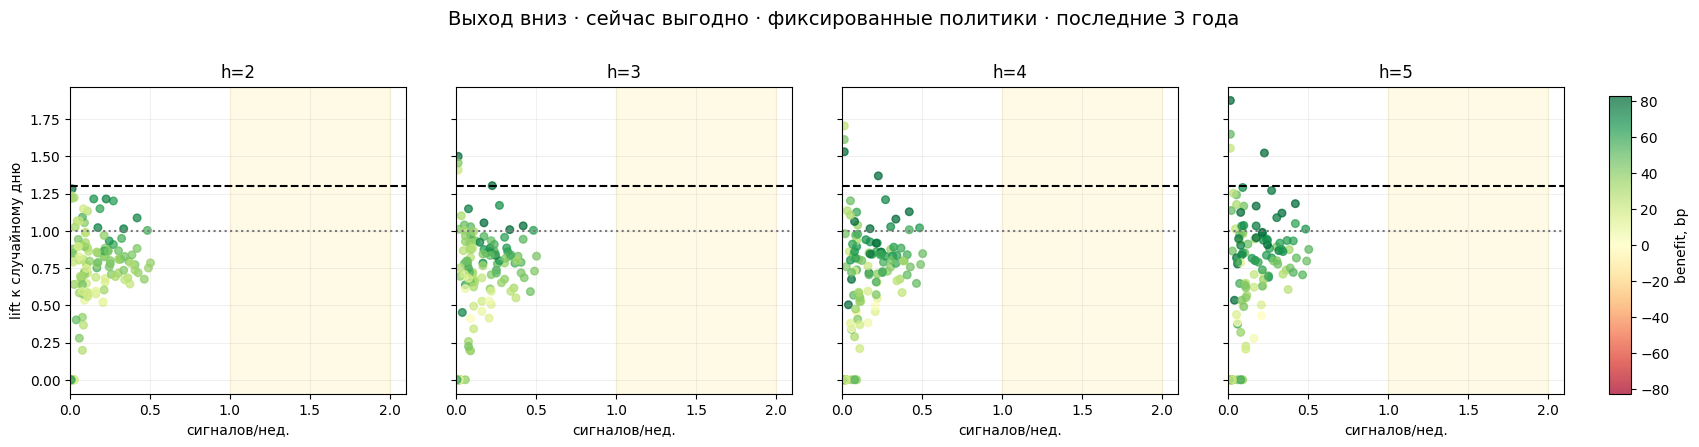

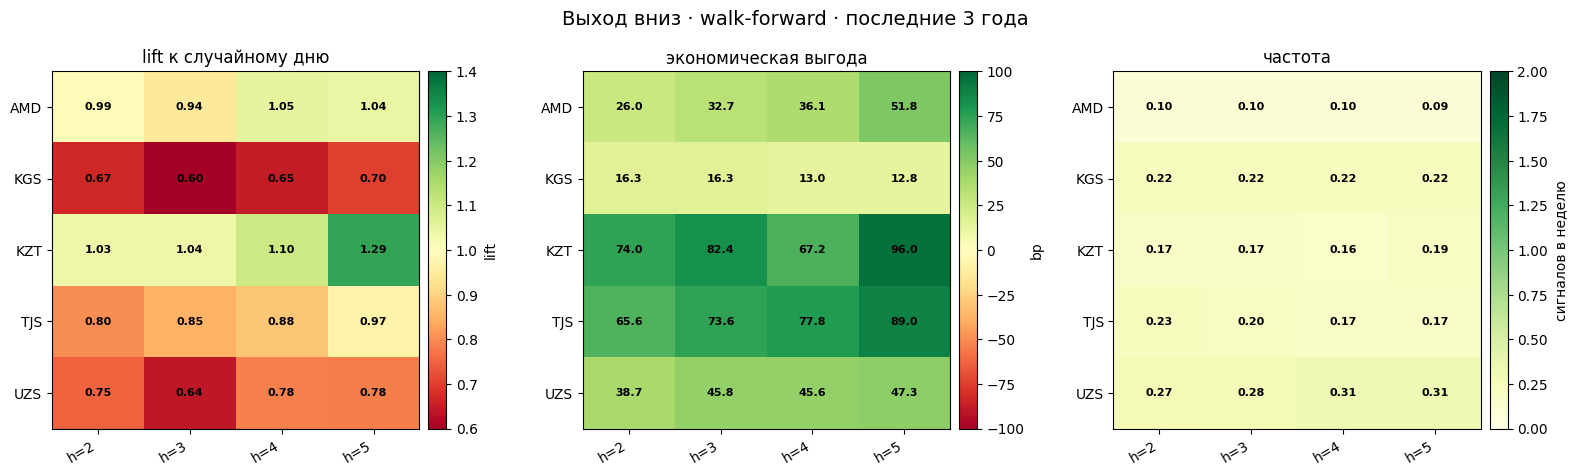

In [7]:
down_fixed = alternative_fixed[alternative_fixed['signal_family'].eq('corridor_exit_down')]
plot_policy_map(down_fixed, 'Выход вниз · сейчас выгодно')

down_wf = alternative_wf[alternative_wf['signal_family'].eq('corridor_exit_down')]
down_recent = alternative_recent[alternative_recent['signal_family'].eq('corridor_exit_down')]
plot_walk_forward_dashboard(down_wf, 'Выход вниз')


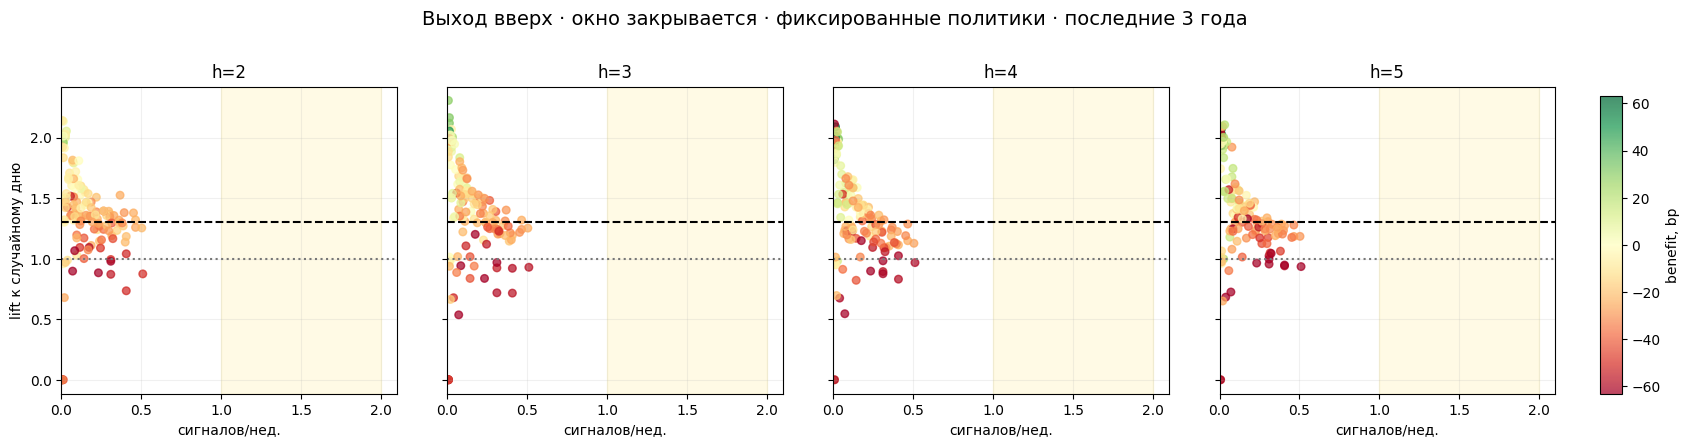

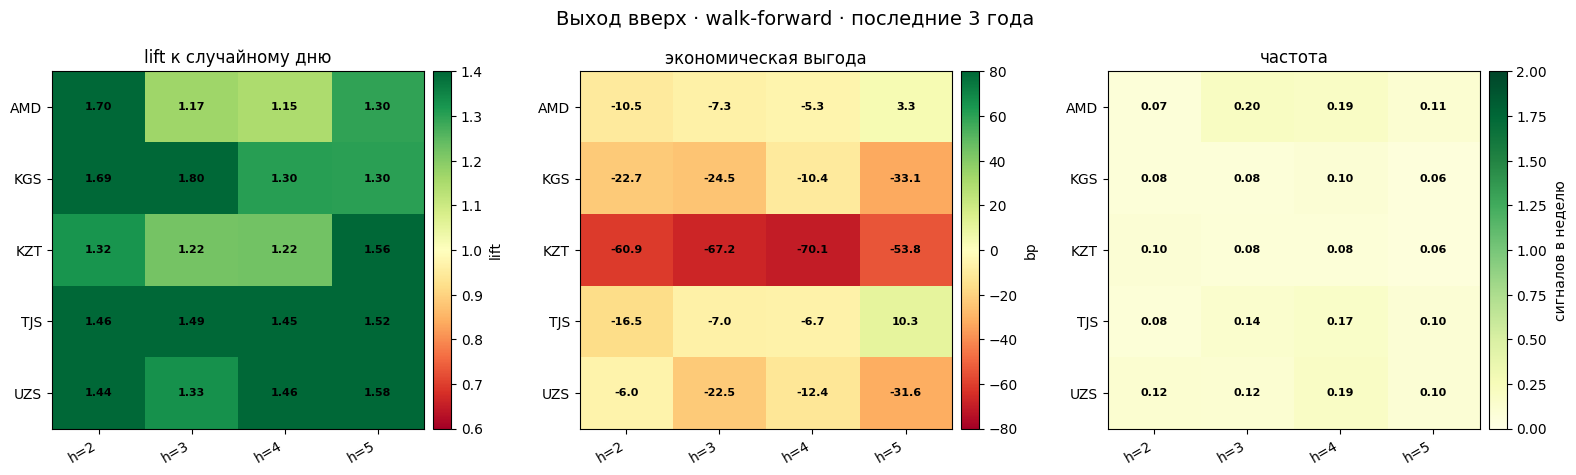

In [8]:
up_fixed = alternative_fixed[alternative_fixed['signal_family'].eq('corridor_exit_up')]
plot_policy_map(up_fixed, 'Выход вверх · окно закрывается')

up_wf = alternative_wf[alternative_wf['signal_family'].eq('corridor_exit_up')]
up_recent = alternative_recent[alternative_recent['signal_family'].eq('corridor_exit_up')]
plot_walk_forward_dashboard(up_wf, 'Выход вверх')


# 4. Отбор hard-пушей

Отбор выполняется по **честным walk-forward результатам последних трёх лет**, а не по лучшей точке на ретроспективной карте. Рабочий допуск к ориентиру кейса — `lift ≥ 1.2`; экономическая выгода должна быть не ниже `−5 bp`.

Устойчивость здесь задана максимально прозрачно: одна семья проходит, только если оба порога выполнены в **каждой** из 20 комбинаций `5 валют × h=2/3/4/5`. На графике поэтому показаны не средние, а худшие значения:

$$
min\_lift=\min_{c,h}\left(\frac{hit\_rate\_signal_{c,h}}{hit\_rate\_random_{c,h}}\right),
$$

$$
min\_benefit=\min_{c,h}(benefit\_bps_{c,h}).
$$

Частота на этом этапе **не является фильтром**: hard-пуши формируют качественное ядро, а недостающую частоту планируется добрать ML-сигналами. Она остаётся в исходных CSV только как диагностика.

После исправления level-target текущий глобальный результат отрицательный: **ни одно семейство и ни одна фиксированная `(L,q)` не проходят пороги устойчиво на всех валютах и h**. Поэтому корректная частота глобального объединения прошедших level-политик равна нулю. Это честный отрицательный результат, прямо предусмотренный кейсом.

При отдельной калибровке коридоров мягкий исследовательский порог на всех четырёх h проходят только `KZT: L=120,q=80%` и `TJS: L=250,q=95%`. Они дают соответственно около `0.43` и `0.12` уникального пуша в неделю после дедупликации/cooldown. Это локальные кандидаты, а не устойчивый результат по всем валютам; строгий порог кейса `lift≥1.3` во всех h не проходит ни один из них.

Почему прежний вывод отличался: сохранение низкого процентильного режима было удобным для level-trigger и структурно давало высокий lift, но не проверяло клиентское решение «перевести сейчас или отложить». Теперь `(L,q)` влияет только на даты сигнала, а hit для «сейчас выгодно» в точности соответствует кейсу.

Дополнительное расхождение с полным протоколом кейса: здесь по ранее принятому решению исследуются `h=2/3/4/5`, тогда как исходный ожидаемый набор — `1/3/5/10/20`. Поэтому даже будущий положительный результат на текущем наборе потребуется подтвердить на пяти исходных горизонтах.


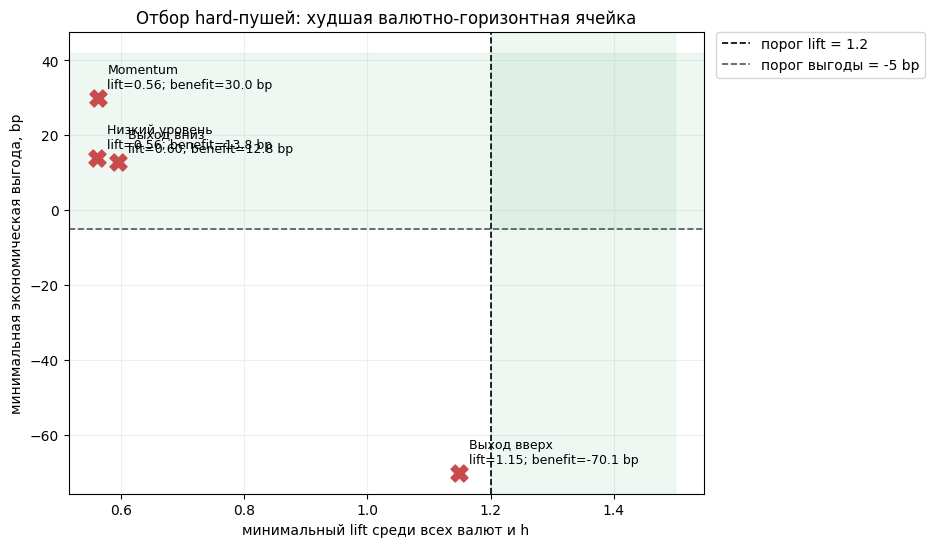

НЕ ПРОХОДИТ НИ ОДНО СЕМЕЙСТВО: хотя бы одна валютно-горизонтная ячейка нарушает пороги.


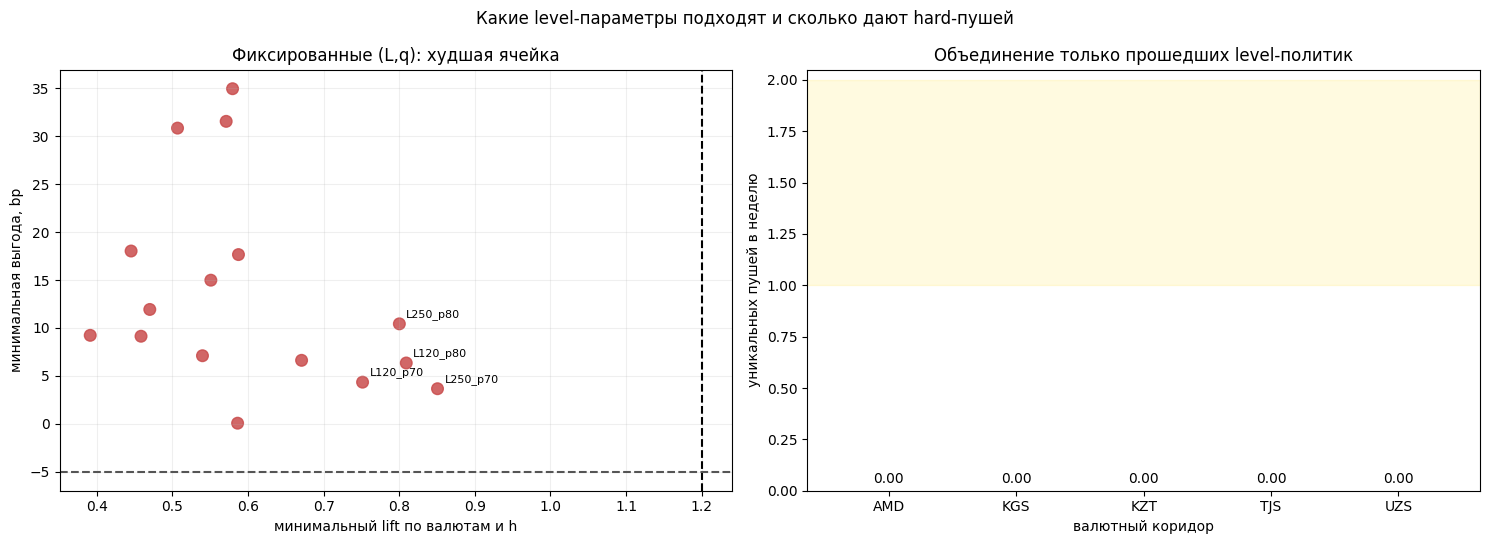

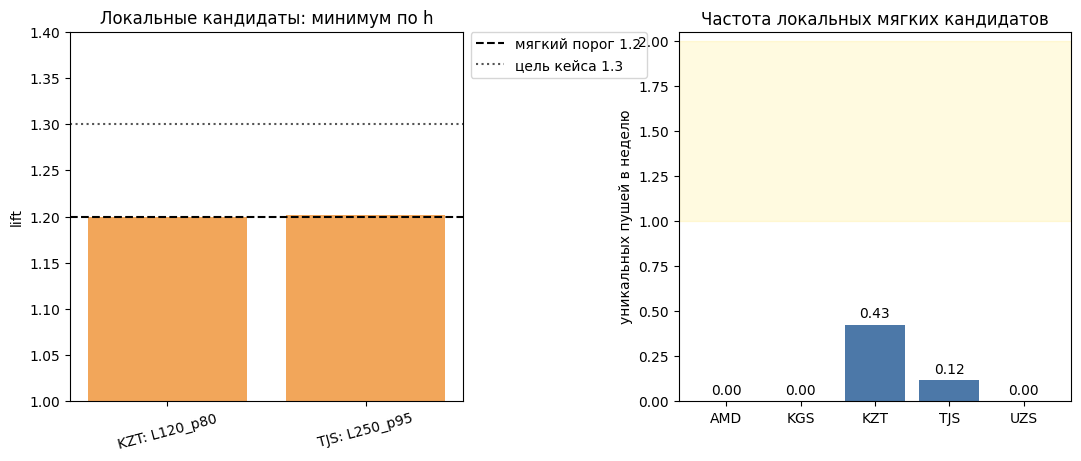

In [9]:
family_labels = {
    'momentum': 'Momentum',
    'level': 'Низкий уровень',
    'corridor_exit_down': 'Выход вниз',
    'corridor_exit_up': 'Выход вверх',
}

fig, ax = plt.subplots(figsize=(10, 6))
x_floor = float(hard_screen['lift_floor'].iloc[0])
y_floor = float(hard_screen['benefit_floor_bps'].iloc[0])
ax.axvspan(x_floor, hard_screen['min_hit_lift'].max() + .35, color='#2ca25f', alpha=.08)
ax.axhspan(y_floor, hard_screen['min_benefit_bps'].max() + 12, color='#2ca25f', alpha=.08)
ax.axvline(x_floor, color='black', linestyle='--', linewidth=1.2, label=f'порог lift = {x_floor:.1f}')
ax.axhline(y_floor, color='#555', linestyle='--', linewidth=1.2, label=f'порог выгоды = {y_floor:.0f} bp')
for _, row in hard_screen.iterrows():
    passed = bool(row['passes_hard_screen'])
    ax.scatter(row['min_hit_lift'], row['min_benefit_bps'], s=150,
               color='#168a45' if passed else '#c94c4c',
               marker='o' if passed else 'X', zorder=3)
    ax.annotate(f"{family_labels[row['signal_family']]}\n"
                f"lift={row['min_hit_lift']:.2f}; benefit={row['min_benefit_bps']:.1f} bp",
                (row['min_hit_lift'], row['min_benefit_bps']),
                xytext=(7, 7), textcoords='offset points', fontsize=9)
ax.set_xlabel('минимальный lift среди всех валют и h')
ax.set_ylabel('минимальная экономическая выгода, bp')
ax.set_title('Отбор hard-пушей: худшая валютно-горизонтная ячейка')
ax.grid(alpha=.2)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.subplots_adjust(right=.76)
plt.show()

qualified = hard_screen.loc[hard_screen['passes_hard_screen']]
if qualified.empty:
    print('НЕ ПРОХОДИТ НИ ОДНО СЕМЕЙСТВО: хотя бы одна валютно-горизонтная ячейка нарушает пороги.')
else:
    for _, winner in qualified.iterrows():
        print(
            f"ПРОХОДИТ: {family_labels[winner['signal_family']]}. "
            f"Худший lift = {winner['min_hit_lift']:.3f} "
            f"({winner['hit_rate_signal_at_worst_lift']:.3f} / "
            f"{winner['hit_rate_random_at_worst_lift']:.3f}). "
            f"Худшая выгода = {winner['min_benefit_bps']:.1f} bp."
        )

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = np.where(level_policy_screen['passes_hard_screen'], '#168a45', '#c94c4c')
axes[0].scatter(level_policy_screen['min_hit_lift'],
                level_policy_screen['min_benefit_bps'], c=colors, s=70, alpha=.85)
axes[0].axvline(1.2, color='black', linestyle='--')
axes[0].axhline(-5, color='#555', linestyle='--')
for _, row in level_policy_screen.head(4).iterrows():
    axes[0].annotate(row['strategy_id'].replace('level_', ''),
                     (row['min_hit_lift'], row['min_benefit_bps']),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[0].set(title='Фиксированные (L,q): худшая ячейка',
            xlabel='минимальный lift по валютам и h',
            ylabel='минимальная выгода, bp')
axes[0].grid(alpha=.2)

axes[1].bar(qualified_level_frequency['currency'],
            qualified_level_frequency['pushes_per_week'], color='#4c78a8')
axes[1].axhspan(1, 2, color='gold', alpha=.12)
axes[1].set_ylim(0, 2.05)
axes[1].set(title='Объединение только прошедших level-политик',
            xlabel='валютный коридор', ylabel='уникальных пушей в неделю')
for index, value in enumerate(qualified_level_frequency['pushes_per_week']):
    axes[1].text(index, value + .04, f'{value:.2f}', ha='center')
fig.suptitle('Какие level-параметры подходят и сколько дают hard-пушей')
fig.tight_layout(); plt.show()

local_candidates = corridor_level_screen.loc[corridor_level_screen['passes_hard_screen']]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
if not local_candidates.empty:
    labels = local_candidates['currency'] + ': ' + local_candidates['strategy_id'].str.replace('level_', '')
    axes[0].bar(labels, local_candidates['min_hit_lift'], color='#f2a65a')
    axes[0].axhline(1.2, color='black', linestyle='--', label='мягкий порог 1.2')
    axes[0].axhline(1.3, color='#555', linestyle=':', label='цель кейса 1.3')
    axes[0].set_ylim(1.0, 1.4)
    axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
axes[0].set(title='Локальные кандидаты: минимум по h', ylabel='lift')
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(corridor_level_frequency['currency'],
            corridor_level_frequency['pushes_per_week'], color='#4c78a8')
axes[1].axhspan(1, 2, color='gold', alpha=.12)
axes[1].set_ylim(0, 2.05)
axes[1].set(title='Частота локальных мягких кандидатов', ylabel='уникальных пушей в неделю')
for index, value in enumerate(corridor_level_frequency['pushes_per_week']):
    axes[1].text(index, value + .04, f'{value:.2f}', ha='center')
fig.subplots_adjust(wspace=.55, right=.84)
plt.show()


## 4.1 Ослабленный порог по отдельным h

Здесь используются только честные walk-forward ячейки, для которых `lift ≥ 1.15` и средний `benefit_bps ≥ 0`. Зелёным отмечены результаты, где выгода также статистически подтверждена: нижняя граница 95% block-bootstrap интервала выше нуля и односторонний `p<0.05`.

Экономически подтверждённые результаты есть только для KZT: momentum на `h=3/4` и выход вниз на `h=5`. На `h=2` подтверждённого relaxed-кандидата нет. Это локальные результаты — ни на одном h семейство не проходит фильтр одновременно по всем пяти валютам.


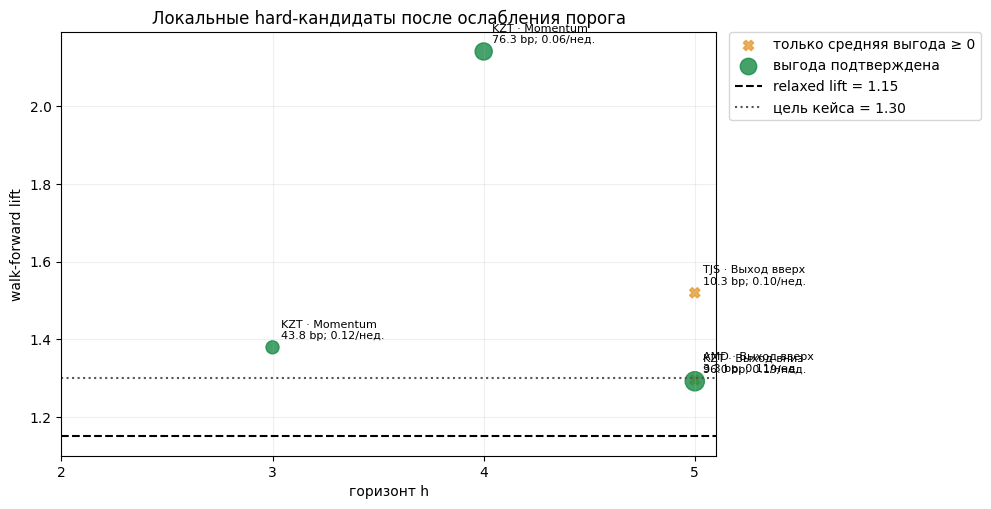

In [10]:
relaxed_labels = {
    'momentum': 'Momentum', 'level': 'Низкий уровень',
    'corridor_exit_down': 'Выход вниз', 'corridor_exit_up': 'Выход вверх',
}
fig, ax = plt.subplots(figsize=(11, 5.5))
for significant, part in relaxed_wf.groupby('benefit_is_significant'):
    ax.scatter(part['horizon'], part['hit_lift'],
               s=np.maximum(55, part['benefit_bps'].clip(lower=0) * 2),
               color='#168a45' if significant else '#e39c35',
               marker='o' if significant else 'X', alpha=.8,
               label='выгода подтверждена' if significant else 'только средняя выгода ≥ 0')
    for _, row in part.iterrows():
        ax.annotate(f"{row['currency']} · {relaxed_labels[row['signal_family']]}\n"
                    f"{row['benefit_bps']:.1f} bp; {row['signals_per_week']:.2f}/нед.",
                    (row['horizon'], row['hit_lift']), xytext=(6, 6),
                    textcoords='offset points', fontsize=8)
ax.axhline(1.15, color='black', linestyle='--', label='relaxed lift = 1.15')
ax.axhline(1.30, color='#555', linestyle=':', label='цель кейса = 1.30')
ax.set_xticks(horizons)
ax.set_xlabel('горизонт h')
ax.set_ylabel('walk-forward lift')
ax.set_title('Локальные hard-кандидаты после ослабления порога')
ax.grid(alpha=.2)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.subplots_adjust(right=.72)
plt.show()
